<a href="https://colab.research.google.com/github/sasurasa/Lin/blob/main/Lin_log120726SS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

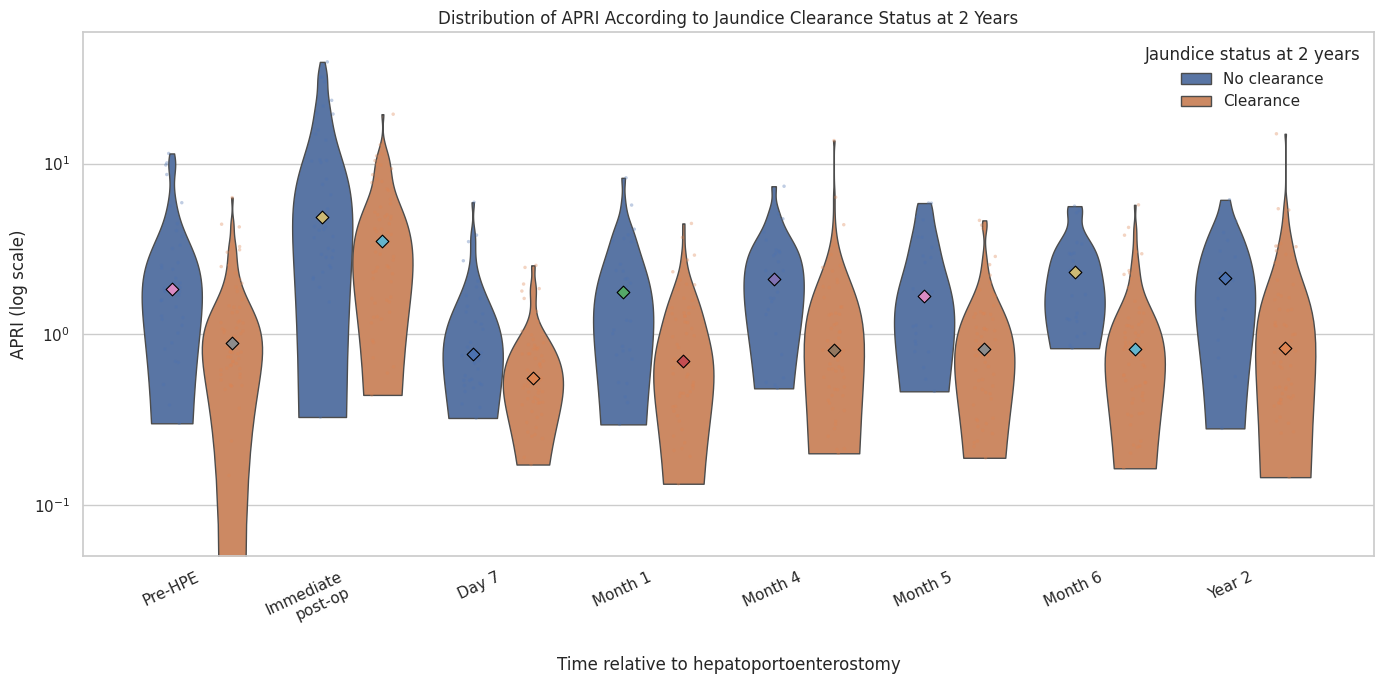

In [2]:
# ============================================================
# Violin plot of APRI over time by 2-year jaundice clearance
# Log-scale y-axis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Read the dataset
# ------------------------------------------------------------

file_path = "/content/apri.xlsx"
sheet_name = "cleanup (2)"
df = pd.read_excel(file_path, sheet_name=sheet_name)

# ------------------------------------------------------------
# 2. Define APRI columns and labels
# ------------------------------------------------------------

apri_columns = [
    "preapri",
    "immapri",
    "d7apri",
    "m1apri",
    "m4apri",
    "m5apri",
    "m6apri",
    "y2apri"
]

time_labels = {
    "preapri": "Pre-HPE",
    "immapri": "Immediate\npost-op",
    "d7apri": "Day 7",
    "m1apri": "Month 1",
    "m4apri": "Month 4",
    "m5apri": "Month 5",
    "m6apri": "Month 6",
    "y2apri": "Year 2"

}

time_order = [time_labels[col] for col in apri_columns]

# ------------------------------------------------------------
# 3. Clean the data
# ------------------------------------------------------------

for col in apri_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["twoyrjclear"] = pd.to_numeric(df["twoyrjclear"], errors="coerce")

# Remove impossible negative values
df[apri_columns] = df[apri_columns].mask(df[apri_columns] < 0)

# Keep only known jaundice-clearance groups
df = df[df["twoyrjclear"].isin([0, 1])].copy()

df["Jaundice clearance"] = df["twoyrjclear"].map({
    0: "No clearance",
    1: "Clearance"
})

# ------------------------------------------------------------
# 4. Convert to long format
# ------------------------------------------------------------

long_df = df.melt(
    id_vars=["Jaundice clearance"],
    value_vars=apri_columns,
    var_name="time_variable",
    value_name="APRI"
)

long_df["Time"] = long_df["time_variable"].map(time_labels)

long_df["Time"] = pd.Categorical(
    long_df["Time"],
    categories=time_order,
    ordered=True
)

# Drop missing APRI and keep only positive APRI for log scale
plot_data = long_df.dropna(subset=["APRI", "Time", "Jaundice clearance"]).copy()
plot_data = plot_data[plot_data["APRI"] > 0].copy()

# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(14, 7))

# Violin plot
# Use density_norm="width" for newer seaborn
# If your seaborn version gives an error, replace with scale="width"
sns.violinplot(
    data=plot_data,
    x="Time",
    y="APRI",
    hue="Jaundice clearance",
    order=time_order,
    hue_order=["No clearance", "Clearance"],
    dodge=True,
    inner=None,
    cut=0,
    density_norm="width",
    linewidth=1,
    ax=ax
)

# Individual observations
sns.stripplot(
    data=plot_data,
    x="Time",
    y="APRI",
    hue="Jaundice clearance",
    order=time_order,
    hue_order=["No clearance", "Clearance"],
    dodge=True,
    jitter=0.15,
    size=2.5,
    alpha=0.35,
    ax=ax
)

# ------------------------------------------------------------
# 6. Overlay medians as diamonds
# ------------------------------------------------------------

median_df = (
    plot_data
    .groupby(["Time", "Jaundice clearance"], observed=True)["APRI"]
    .median()
    .reset_index()
)

offsets = {
    "No clearance": -0.20,
    "Clearance": 0.20
}

for time_index, time_point in enumerate(time_order):
    for group in ["No clearance", "Clearance"]:
        median_value = median_df.loc[
            (median_df["Time"] == time_point) &
            (median_df["Jaundice clearance"] == group),
            "APRI"
        ]

        if not median_value.empty:
            ax.scatter(
                time_index + offsets[group],
                median_value.iloc[0],
                marker="D",
                s=42,
                edgecolor="black",
                linewidth=0.8,
                zorder=10
            )

# ------------------------------------------------------------
# 7. Fix legend
# ------------------------------------------------------------

handles, labels = ax.get_legend_handles_labels()

# violinplot + stripplot both create legend entries
ax.legend(
    handles[:2],
    labels[:2],
    title="Jaundice status at 2 years",
    frameon=False,
    loc="upper right"
)

# ------------------------------------------------------------
# 8. Log-scale formatting
# ------------------------------------------------------------

ax.set_yscale("log")
ax.set_ylim(0.05, None)

ax.set_xlabel(
    "Time relative to hepatoportoenterostomy",
    labelpad=16
)

ax.set_ylabel("APRI (log scale)")

ax.set_title(
    "Distribution of APRI According to Jaundice Clearance Status at 2 Years"
)

ax.tick_params(axis="x", labelrotation=25)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

ax.grid(axis="x", visible=False)

fig.subplots_adjust(bottom=0.24)
plt.tight_layout()

# ------------------------------------------------------------
# 9. Save figure
# ------------------------------------------------------------

plt.savefig(
    "APRI_violin_logscale_by_2year_jaundice_clearance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "APRI_violin_logscale_by_2year_jaundice_clearance.pdf",
    bbox_inches="tight"
)

plt.show()